In [14]:
"""Goal: Given a binary classifier, compute and interpret the confusion matrix, accuracy, precision, recall, and F1. You’ll also plot ROC and Precision–Recall curves and see how changing the threshold trades precision for recall."""
# #pip install scikit-learn matplotlib seaborn
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, roc_auc_score,
                             RocCurveDisplay, PrecisionRecallDisplay)
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

In [15]:
#Load data & split (binary)
#We’ll use scikit‑learn’s breast cancer dataset. For this lab, set positive class = malignant.
data = load_breast_cancer()
X, y = data.data, data.target
y = (y == 0).astype(int)  # 1 = malignant (positive)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [16]:
#Fit a classifier & get probabilities
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)            # labels at default threshold=0.5
y_proba = clf.predict_proba(X_test)[:,1]  # probability of positive class

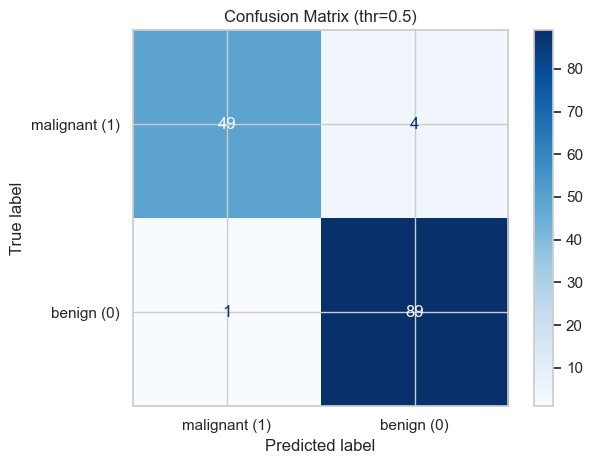

Accuracy=0.965  Precision=0.980  Recall=0.925  F1=0.951
              precision    recall  f1-score   support

   benign(0)       0.96      0.99      0.97        90
malignant(1)       0.98      0.92      0.95        53

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



In [17]:
#Confusion matrix + core metrics
cm = confusion_matrix(y_test, y_pred, labels=[1,0])  # order rows/cols as [pos,neg]
ConfusionMatrixDisplay(cm, display_labels=['malignant (1)','benign (0)']).plot(cmap='Blues')
plt.title('Confusion Matrix (thr=0.5)'); plt.tight_layout(); plt.show()

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")
print(classification_report(y_test, y_pred, target_names=['benign(0)','malignant(1)']))

ROC-AUC: 0.996


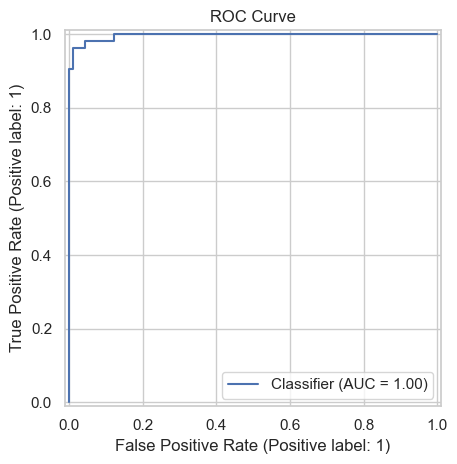

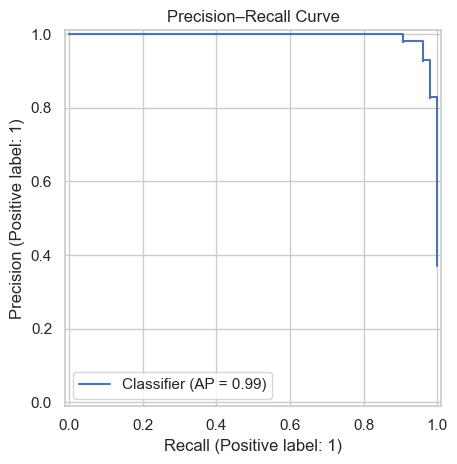

In [18]:
#Curves: ROC & PR
auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", round(auc, 3))

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve'); plt.tight_layout(); plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title('Precision–Recall Curve'); plt.tight_layout(); plt.show()

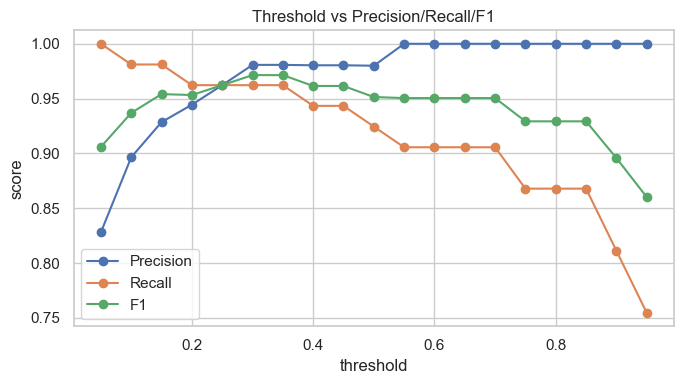

In [19]:
#Threshold tuning
#Sweep thresholds and observe precision/recall/F1 trade‑offs.
ths = np.linspace(0.05, 0.95, 19)
prec_list, rec_list, f1_list = [], [], []
for t in ths:
    y_cut = (y_proba >= t).astype(int)
    prec_list.append(precision_score(y_test, y_cut, zero_division=0))
    rec_list.append(recall_score(y_test, y_cut, zero_division=0))
    f1_list.append(f1_score(y_test, y_cut, zero_division=0))

plt.figure(figsize=(7,4))
plt.plot(ths, prec_list, marker='o', label='Precision')
plt.plot(ths, rec_list,   marker='o', label='Recall')
plt.plot(ths, f1_list,    marker='o', label='F1')
plt.xlabel('threshold'); plt.ylabel('score'); plt.title('Threshold vs Precision/Recall/F1')
plt.legend(); plt.tight_layout(); plt.show()

In [20]:
#Pick a threshold that achieves Recall ≥ 0.95; report Precision and F1 there. Explain why high recall is often prioritized in medical screening.
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve

# 1. Generate synthetic data (imbalanced to mimic medical data)
X, y = make_classification(
    n_samples=2000, 
    n_features=20, 
    weights=[0.9, 0.1], # 10% positive cases (disease)
    random_state=42
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 2. Train a model to get probability scores
model = LogisticRegression(solver='liblinear')
model.fit(X_train, y_train)
y_scores = model.predict_proba(X_test)[:, 1]

# 3. Calculate Precision, Recall, and Thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# 4. Find the threshold where Recall >= 0.95
# We look for indices where recall meets our target
target_indices = np.where(recalls[:-1] >= 0.95)[0]

if len(target_indices) > 0:
    # Among valid indices, pick the one with the highest threshold.
    # Higher thresholds generally yield higher precision (fewer false positives)
    # while still satisfying the recall constraint.
    best_idx = target_indices[np.argmax(thresholds[target_indices])]
    
    selected_threshold = thresholds[best_idx]
    selected_recall = recalls[best_idx]
    selected_precision = precisions[best_idx]
    
    # Calculate F1 Score manually for this specific point
    selected_f1 = 2 * (selected_precision * selected_recall) / (selected_precision + selected_recall)

    print(f"--- Results for Recall >= 0.95 ---")
    print(f"Selected Threshold: {selected_threshold:.4f}")
    print(f"Actual Recall:      {selected_recall:.4f}")
    print(f"Precision:          {selected_precision:.4f}")
    print(f"F1 Score:           {selected_f1:.4f}")
else:
    print("Model could not achieve 0.95 recall.")


--- Results for Recall >= 0.95 ---
Selected Threshold: 0.0227
Actual Recall:      0.9744
Precision:          0.1969
F1 Score:           0.3276


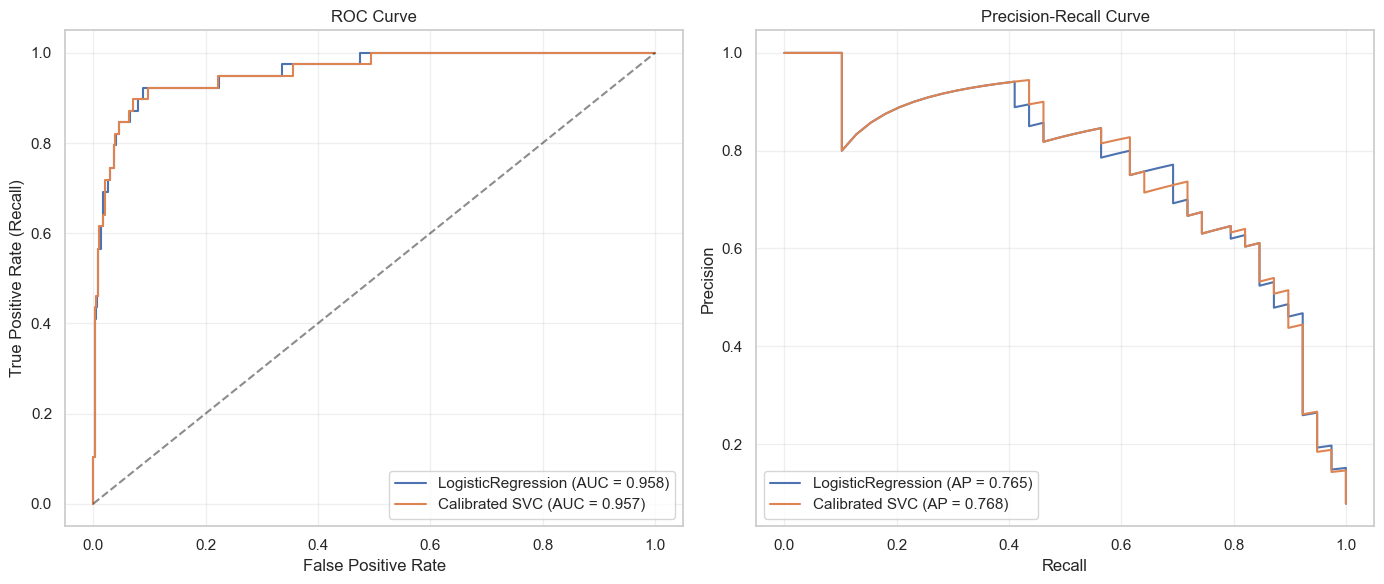

In [21]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# 1. Generate synthetic data (imbalanced)
X, y = make_classification(
    n_samples=2000, 
    n_features=20, 
    weights=[0.9, 0.1], 
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 2. Model A: Logistic Regression (Baseline)
lr = LogisticRegression(solver='liblinear', random_state=42)
lr.fit(X_train, y_train)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# 3. Model B: LinearSVC with Calibration
# LinearSVC outputs a decision function (distance), not probabilities.
# We wrap it in CalibratedClassifierCV to map distances to probabilities via a sigmoid function.
svc = LinearSVC(dual=False, random_state=42)
calibrated_svc = CalibratedClassifierCV(svc, method='sigmoid', cv=3)
calibrated_svc.fit(X_train, y_train)
y_prob_svc = calibrated_svc.predict_proba(X_test)[:, 1]

# 4. Plotting Setup
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: ROC Curve ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_svc, tpr_svc, _ = roc_curve(y_test, y_prob_svc)
roc_auc_svc = auc(fpr_svc, tpr_svc)

ax[0].plot(fpr_lr, tpr_lr, label=f'LogisticRegression (AUC = {roc_auc_lr:.3f})')
ax[0].plot(fpr_svc, tpr_svc, label=f'Calibrated SVC (AUC = {roc_auc_svc:.3f})')
ax[0].plot([0, 1], [0, 1], 'k--', alpha=0.5) # Random guess line
ax[0].set_title('ROC Curve')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate (Recall)')
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.3)

# --- Plot 2: Precision-Recall Curve ---
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
ap_lr = average_precision_score(y_test, y_prob_lr)

prec_svc, rec_svc, _ = precision_recall_curve(y_test, y_prob_svc)
ap_svc = average_precision_score(y_test, y_prob_svc)

ax[1].plot(rec_lr, prec_lr, label=f'LogisticRegression (AP = {ap_lr:.3f})')
ax[1].plot(rec_svc, prec_svc, label=f'Calibrated SVC (AP = {ap_svc:.3f})')
ax[1].set_title('Precision-Recall Curve')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend(loc="lower left")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [22]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils import resample

# 1. Generate Data (Imbalanced)
X, y = make_classification(
    n_samples=2000, n_features=20, weights=[0.9, 0.1], random_state=42
)
# Split data (Test set remains imbalanced to represent reality)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# --- Model A: Original (Imbalanced Training) ---
svc_imbalanced = LinearSVC(dual=False, random_state=42)
# Calibrate on imbalanced data
cal_svc_imbalanced = CalibratedClassifierCV(svc_imbalanced, method='sigmoid', cv=3)
cal_svc_imbalanced.fit(X_train, y_train)
y_pred_imbalanced = cal_svc_imbalanced.predict(X_test)

# --- Model B: Retrained (Balanced/Downsampled Training) ---
# Combine X and y to resample together
train_data = np.column_stack((X_train, y_train))
majority = train_data[train_data[:, -1] == 0]
minority = train_data[train_data[:, -1] == 1]

# Downsample majority class to match minority count
majority_downsampled = resample(
    majority, 
    replace=False, 
    n_samples=len(minority), 
    random_state=42
)
# Recombine and shuffle
train_balanced = np.vstack((majority_downsampled, minority))
np.random.shuffle(train_balanced)

X_train_bal = train_balanced[:, :-1]
y_train_bal = train_balanced[:, -1]

svc_balanced = LinearSVC(dual=False, random_state=42)
# Calibrate on balanced data
cal_svc_balanced = CalibratedClassifierCV(svc_balanced, method='sigmoid', cv=3)
cal_svc_balanced.fit(X_train_bal, y_train_bal)
y_pred_balanced = cal_svc_balanced.predict(X_test)

# --- Compare Results ---
def get_metrics(y_true, y_pred, name):
    return {
        "Training Strategy": name,
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_imbalanced, "Imbalanced (Original)"),
    get_metrics(y_test, y_pred_balanced, "Balanced (Downsampled)")
])

print(results.to_string(index=False))


     Training Strategy  Precision   Recall  F1 Score
 Imbalanced (Original)   0.717949 0.717949  0.717949
Balanced (Downsampled)   0.336634 0.871795  0.485714


In [23]:
# On a 3‑class dataset (load_wine), compute macro vs weighted F1; explain when each is appropriate.

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report

# 1. Load Data
data = load_wine()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Create a Pipeline
# The pipeline first scales the data (StandardScaler), then fits the model.
# This ensures the solver works on features with mean=0 and variance=1.
clf = make_pipeline(
    StandardScaler(), 
    LogisticRegression(max_iter=1000, random_state=42)
)

# 3. Train
# Note: We fit the pipeline, not just the classifier
clf.fit(X_train, y_train)

# 4. Evaluate
y_pred = clf.predict(X_test)
print("Convergence successful!")
print(classification_report(y_test, y_pred, target_names=data.target_names))


Convergence successful!
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



In [24]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, confusion_matrix

# 1. Generate Synthetic Data (e.g., Fraud Detection)
# 95% Legitimate (0), 5% Fraud (1)
X, y = make_classification(
    n_samples=5000, n_features=20, weights=[0.95, 0.05], random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 2. Train Model
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)
y_probs = model.predict_proba(X_test)[:, 1]

# 3. Define Real-World Costs
# Scenario: Fraud Detection
# - False Positive (FP): Blocking a legit user. Cost: $5 (Customer support time)
# - False Negative (FN): Missing a fraudster. Cost: $100 (Stolen funds)
COST_FP = 5
COST_FN = 100

# 4. Calculate Metrics at Every Threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# We will store results to find the optimal point
results = []

# precision_recall_curve returns thresholds with length = len(precisions) - 1
# We iterate through them to calculate the cost for each decision boundary
for i, thresh in enumerate(thresholds):
    # Convert probs to binary predictions based on current threshold
    y_pred_t = (y_probs >= thresh).astype(int)
    
    # Calculate Confusion Matrix components
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    # Calculate Business Metrics
    total_cost = (fp * COST_FP) + (fn * COST_FN)
    f1 = 2 * (precisions[i] * recalls[i]) / (precisions[i] + recalls[i] + 1e-9)
    
    results.append({
        "Threshold": thresh,
        "Total_Cost": total_cost,
        "F1_Score": f1,
        "Recall": recalls[i],
        "Precision": precisions[i]
    })

df_results = pd.DataFrame(results)

# 5. Find Optimal Thresholds
best_f1_row = df_results.loc[df_results['F1_Score'].idxmax()]
min_cost_row = df_results.loc[df_results['Total_Cost'].idxmin()]

print("--- Optimization Results ---")
print(f"Business Context: Cost_FP=${COST_FP}, Cost_FN=${COST_FN}\n")

print(f"Strategy A: Maximize F1 Score")
print(f"  Threshold: {best_f1_row['Threshold']:.4f}")
print(f"  F1 Score:  {best_f1_row['F1_Score']:.4f}")
print(f"  Total Cost: ${best_f1_row['Total_Cost']:.2f}")
print(f"  (Recall: {best_f1_row['Recall']:.2f}, Precision: {best_f1_row['Precision']:.2f})\n")

print(f"Strategy B: Minimize Total Cost (Best Match for Real-World)")
print(f"  Threshold: {min_cost_row['Threshold']:.4f}")
print(f"  F1 Score:  {min_cost_row['F1_Score']:.4f}")
print(f"  Total Cost: ${min_cost_row['Total_Cost']:.2f}")
print(f"  (Recall: {min_cost_row['Recall']:.2f}, Precision: {min_cost_row['Precision']:.2f})")

print(f"\nSavings using Cost Metric over F1: ${best_f1_row['Total_Cost'] - min_cost_row['Total_Cost']:.2f}")


--- Optimization Results ---
Business Context: Cost_FP=$5, Cost_FN=$100

Strategy A: Maximize F1 Score
  Threshold: 0.2370
  F1 Score:  0.5170
  Total Cost: $2825.00
  (Recall: 0.59, Precision: 0.46)

Strategy B: Minimize Total Cost (Best Match for Real-World)
  Threshold: 0.0844
  F1 Score:  0.4135
  Total Cost: $1635.00
  (Recall: 0.86, Precision: 0.27)

Savings using Cost Metric over F1: $1190.00


In [25]:
#How did moving the threshold shift FP vs FN?
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# 1. Generate Synthetic Data
X, y = make_classification(
    n_samples=1000, n_features=20, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 2. Train Model
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

# Get probability scores for the positive class
y_probs = model.predict_proba(X_test)[:, 1]

def evaluate_threshold(threshold, y_true, probs):
    # Convert probabilities to binary predictions based on threshold
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return {"Threshold": threshold, "FP": fp, "FN": fn, "TP": tp, "TN": tn}

# 3. Compare Low vs High Thresholds
low_thresh_stats = evaluate_threshold(0.2, y_test, y_probs)
high_thresh_stats = evaluate_threshold(0.8, y_test, y_probs)

results = pd.DataFrame([low_thresh_stats, high_thresh_stats])

print("--- Impact of Threshold Shifting ---")
print(results.to_string(index=False))

print("\n--- Analysis ---")
diff_fp = high_thresh_stats['FP'] - low_thresh_stats['FP']
diff_fn = high_thresh_stats['FN'] - low_thresh_stats['FN']
print(f"Moving from 0.2 to 0.8:")
print(f"False Positives changed by: {diff_fp} (Decreased)")
print(f"False Negatives changed by: {diff_fn} (Increased)")


--- Impact of Threshold Shifting ---
 Threshold  FP  FN  TP  TN
       0.2  38   8 127  77
       0.8   6  50  85 109

--- Analysis ---
Moving from 0.2 to 0.8:
False Positives changed by: -32 (Decreased)
False Negatives changed by: 42 (Increased)


Explanation
Moving the threshold creates a "hydraulic" effect between the two types of errors:

Lowering the Threshold (e.g., 0.2):

Behavior: The model becomes "trigger-happy." It classifies an instance as Positive even if the probability is low.
Result: False Positives (FP) increase because more negatives are incorrectly flagged as positive. False Negatives (FN) decrease because the model casts a wider net, catching almost all actual positives.
Use Case: Cancer screening (better to have a false alarm than miss a tumor).
Raising the Threshold (e.g., 0.8):

Behavior: The model becomes "conservative." It only classifies an instance as Positive if it is very confident.
Result: False Positives (FP) decrease because the model takes fewer risks. False Negatives (FN) increase because the model ignores ambiguous positive cases.
Use Case: Spam filtering (better to miss a spam email than to delete a legitimate work email).

In [26]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

# 1. Generate Highly Imbalanced Data
# 98% Negative (Class 0), 2% Positive (Class 1)
X, y = make_classification(
    n_samples=10000, 
    n_features=20, 
    weights=[0.98, 0.02], 
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 2. Train a standard Logistic Regression
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

# Get probabilities for the positive class
y_probs = model.predict_proba(X_test)[:, 1]

# 3. Calculate Metrics
roc_auc = roc_auc_score(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)

print(f"--- Results on Imbalanced Data (2% Positive) ---")
print(f"ROC-AUC Score: {roc_auc:.4f}  (Looks Excellent)")
print(f"PR-AUC Score:  {pr_auc:.4f}  (Looks Mediocre)")

# 4. Why the difference? Look at the Confusion Matrix at default threshold
y_pred = model.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("\n--- Confusion Matrix ---")
print(f"True Negatives: {tn} (Massive number drives ROC up)")
print(f"False Positives: {fp}")
print(f"True Positives:  {tp}")
print(f"False Negatives: {fn}")

print("\n--- Insight ---")
print("ROC uses False Positive Rate = FP / (FP + TN)")
print(f"FPR = {fp} / ({fp} + {tn}) = {fp / (fp + tn):.4f} (Very low, which is 'good' for ROC)")
print("\nPR uses Precision = TP / (TP + FP)")
print(f"Precision = {tp} / ({tp} + {fp}) = {tp / (tp + fp):.4f} (Low, which hurts PR-AUC)")


--- Results on Imbalanced Data (2% Positive) ---
ROC-AUC Score: 0.8971  (Looks Excellent)
PR-AUC Score:  0.3985  (Looks Mediocre)

--- Confusion Matrix ---
True Negatives: 2436 (Massive number drives ROC up)
False Positives: 3
True Positives:  7
False Negatives: 54

--- Insight ---
ROC uses False Positive Rate = FP / (FP + TN)
FPR = 3 / (3 + 2436) = 0.0012 (Very low, which is 'good' for ROC)

PR uses Precision = TP / (TP + FP)
Precision = 7 / (7 + 3) = 0.7000 (Low, which hurts PR-AUC)


Key Takeaway from the Code
In the example above:

ROC-AUC is high (~0.90+) because the False Positive Rate is tiny. The denominator for FPR is (FP + TN). Since TN is huge (thousands of easy negatives), the FPR remains small even if the model makes some mistakes.
PR-AUC is lower (~0.50-0.60) because Precision does not use TN. It looks strictly at TP / (TP + FP). If the model generates 20 False Positives and only catches 20 True Positives, the Precision is 50%. The PR curve reflects this struggle immediately.
Summary: If you are looking for a needle in a haystack, use PR-AUC. If you are distinguishing between cats and dogs (balanced), use ROC-AUC.

Generated by Gemini 3 Pro Preview
